In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import os

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#DataSet 1 (Health Care)
path_health = kagglehub.dataset_download("rabieelkharoua/chronic-kidney-disease-dataset-analysis")
print("Path to dataset files:", path_health)

#DataSet 2 (Marketing)
path_marketing = kagglehub.dataset_download("rodsaldanha/arketing-campaign")
print("Path to dataset files:", path_marketing)

#DataSet 3 (Energy)
path_energy = kagglehub.dataset_download("guillemservera/fuels-futures-data")
print("Path to dataset files:", path_energy)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/rabieelkharoua/chronic-kidney-disease-dataset-analysis/versions/1
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/rodsaldanha/arketing-campaign/versions/8
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/guillemservera/fuels-futures-data/versions/191


In [3]:
#Health Dataframe
path_to_file = os.path.join(path_health, "Chronic_Kidney_Dsease_data.csv")
df_health = pd.read_csv(path_to_file)

#Marketing Dataframe
path_to_file_two = os.path.join(path_marketing, "marketing_campaign.csv")
df_marketing = pd.read_csv(path_to_file_two, sep=";")

#Energy Dataframe
path_to_file_three = os.path.join(path_energy, "all_fuels_data.csv")
df_energy = pd.read_csv(path_to_file_three)

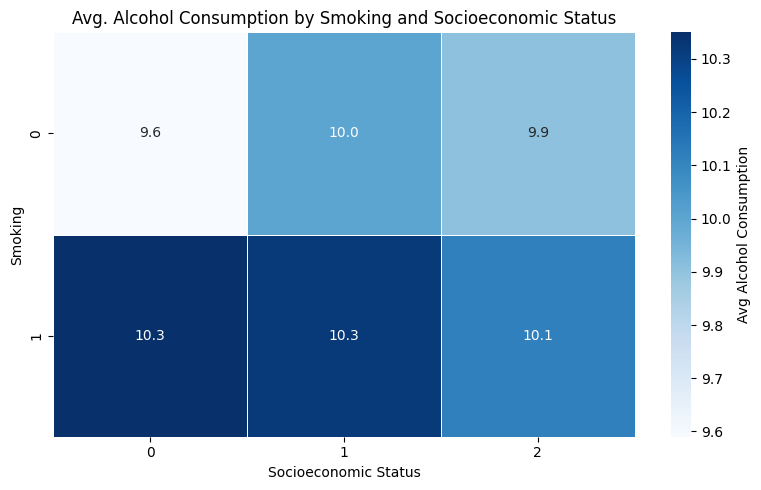

In [4]:
#Smoking, Social Status and Alcohol Consumption 
pivot_mean = df_health.pivot_table(
    index='Smoking',
    columns='SocioeconomicStatus',
    values='AlcoholConsumption',
    aggfunc='mean'
)

# Plot Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={'label': 'Avg Alcohol Consumption'},
    linewidths=0.5,
    square=False
)

# Labels
plt.title("Avg. Alcohol Consumption by Smoking and Socioeconomic Status")
plt.ylabel("Smoking")
plt.xlabel("Socioeconomic Status")
plt.tight_layout()
plt.show()



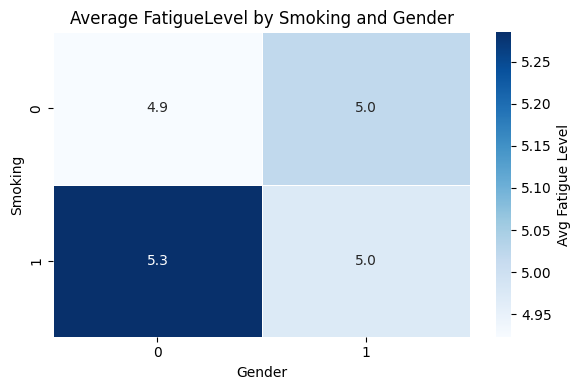

In [5]:
# Smoking, Gender, & Fatigue Level
pivot_mean = df_health.pivot_table(
    index="Smoking",
    columns="Gender",
    values="FatigueLevels",
    aggfunc="mean"
)
# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Avg Fatigue Level"},
    linewidths=0.5
)
plt.title("Average FatigueLevel by Smoking and Gender")
plt.ylabel("Smoking")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()

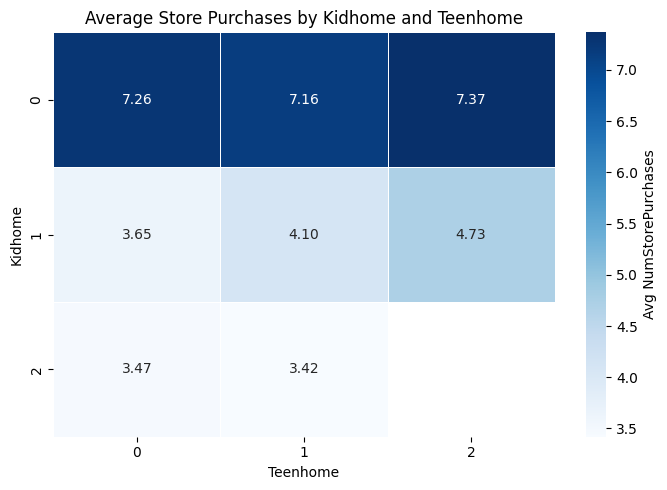

In [6]:
# Marketing Kid at home, teen at home, number of store purchases
pivot_mean = df_marketing.pivot_table(
    index="Kidhome",
    columns="Teenhome",
    values="NumStorePurchases",
    aggfunc="mean"
)
# Plot
plt.figure(figsize=(7, 5))
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Avg NumStorePurchases"},
    linewidths=0.5
)

# Labels
plt.title("Average Store Purchases by Kidhome and Teenhome")
plt.ylabel("Kidhome")
plt.xlabel("Teenhome")
plt.tight_layout()
plt.show()



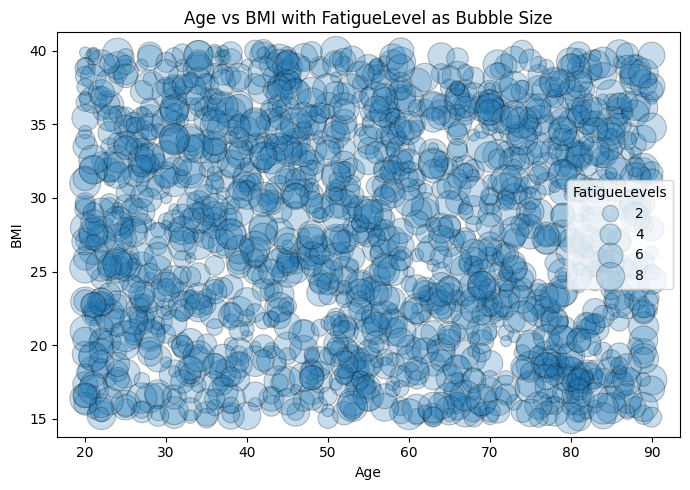

In [7]:
# Bubble BMI, Age, to Fatigue  

subset = df_health[["FatigueLevels", "BMI", "Age"]].dropna()

# Plot
plt.figure(figsize=(7, 5))
ax = sns.scatterplot(
    data=subset,
    x="Age",
    y="BMI",
    size="FatigueLevels",                    
    sizes=(50, 500),              
    alpha=0.25,
    edgecolor="k",
    legend="brief"
)
ax.set_xlabel("Age")
ax.set_ylabel("BMI")
ax.set_title("Age vs BMI with FatigueLevel as Bubble Size")


handles, labels = ax.get_legend_handles_labels()

plt.tight_layout()
plt.show()

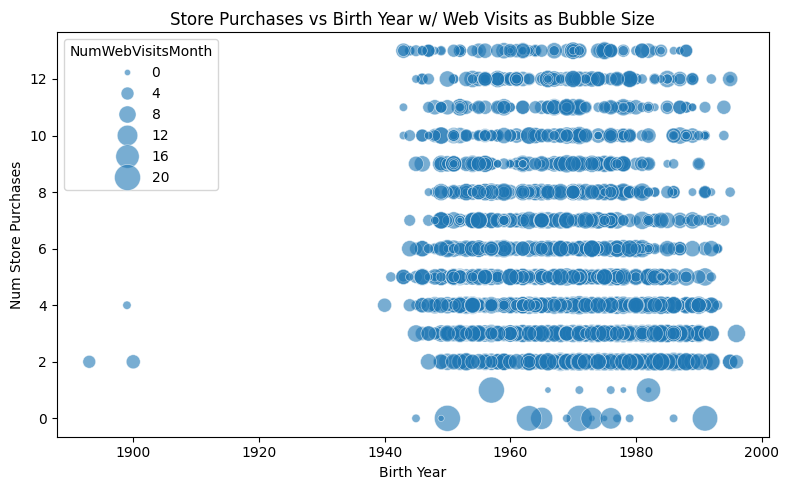

In [8]:
# Bubble Marketing 
plot_df = df_marketing[["Year_Birth", "NumStorePurchases", "NumWebVisitsMonth"]].dropna()

# Plot
plt.figure(figsize=(8, 5))
ax = sns.scatterplot(
    data=plot_df,
    x="Year_Birth",
    y="NumStorePurchases",
    size="NumWebVisitsMonth",
    sizes=(20, 350), 
    alpha=0.6,
    edgecolor="w",
    linewidth=0.5,
    legend="brief"
)
ax.set_title("Store Purchases vs Birth Year w/ Web Visits as Bubble Size")
ax.set_xlabel("Birth Year")
ax.set_ylabel("Num Store Purchases")

handles, labels = ax.get_legend_handles_labels()

plt.tight_layout()
plt.show()



In [9]:
# Change confidential to Nan
df_health["DoctorInCharge"] = df_health["DoctorInCharge"].replace("Confidential", np.nan)



/tmp/ipykernel_2459/1291770701.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_health["DoctorInCharge"] = df_health["DoctorInCharge"].replace("Confidential", np.nan)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.92      1.00      0.96       305

    accuracy                           0.92       332
   macro avg       0.46      0.50      0.48       332
weighted avg       0.84      0.92      0.88       332

ROC AUC: 0.7942926533090469


/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


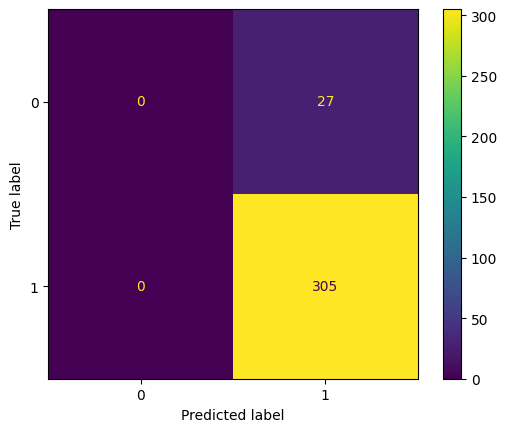

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# Set x/y
y = df_health["Diagnosis"]  
X = df_health.drop(columns=["Diagnosis", "PatientID"])

# X train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

# Categorical Columns 
categorical_cols = [
    "Gender",
    "Ethnicity",
    "SocioeconomicStatus",
    "EducationLevel",
    "FamilyHistoryKidneyDisease",
    "FamilyHistoryHypertension",
    "FamilyHistoryDiabetes",
    "PreviousAcuteKidneyInjury",
    "UrinaryTractInfections",
   
]
# Numeric Columns
numeric_cols = [c for c in X.columns if c not in categorical_cols]

# Pre-Transform
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ],
    remainder="drop"
)

# Pipeline
pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        random_state=0,
        class_weight="balanced",  
        n_estimators=200,
        max_depth=None,
        n_jobs=-1
    )),
])


pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  

print("Classification report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion Matrix 
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)


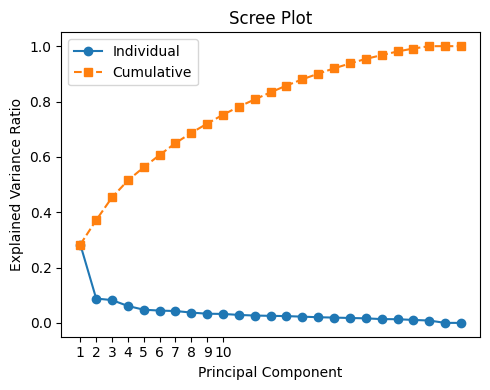

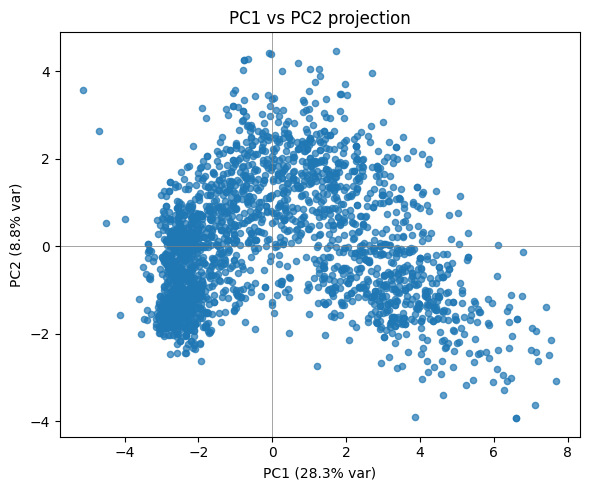

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Marketing PCA
X = df_marketing.copy()

# Drop 
for drop in ["ID"]:
    if drop in X.columns:
        X = X.drop(columns=[drop])

numeric = X.select_dtypes(include=["number"]).copy()

# Pipeline
preprocess_and_pca = Pipeline([
    ("impute", SimpleImputer(strategy="median")),       
    ("scale", StandardScaler()),                        
    ("pca_full", PCA())                                
])

Z = preprocess_and_pca.fit_transform(numeric)  


pca_obj = preprocess_and_pca.named_steps["pca_full"]
explained = pca_obj.explained_variance_ratio_

plt.figure(figsize=(5,4))
components = np.arange(1, len(explained) + 1)
plt.plot(components, explained, "o-", label="Individual")
plt.plot(components, np.cumsum(explained), "s--", label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(components[:10])
plt.legend()
plt.tight_layout()
plt.show()

# Scatter 
pca2 = PCA(n_components=2)
pc_scores = pca2.fit_transform(preprocess_and_pca.named_steps["scale"].transform(
    preprocess_and_pca.named_steps["impute"].transform(numeric)
))
pc_df = pd.DataFrame(pc_scores, columns=["PC1", "PC2"])

plt.figure(figsize=(6,5))
plt.scatter(pc_df["PC1"], pc_df["PC2"], alpha=0.7, s=20)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 projection")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()


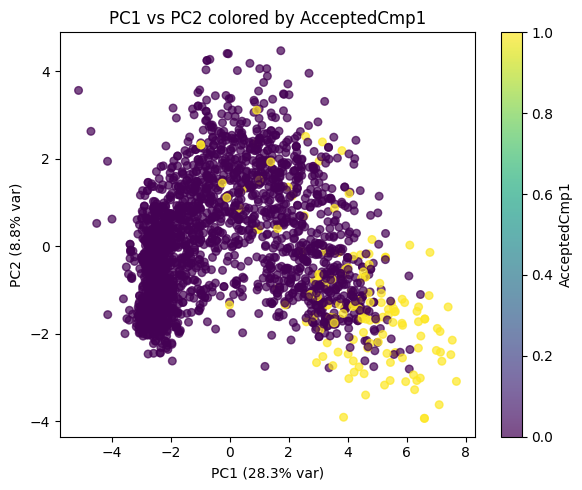

In [12]:
# Response checks
response = df_marketing["AcceptedCmp1"].reset_index(drop=True) 

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    pc_df["PC1"], pc_df["PC2"],
    c=response,                
    cmap="viridis",           
    alpha=0.7,
    s=30
)
plt.colorbar(scatter, label="AcceptedCmp1")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 colored by AcceptedCmp1")
plt.tight_layout()
plt.show()


=== Logistic Regression on PC1/PC2 ===
              precision    recall  f1-score   support

           0       0.99      0.85      0.91       419
           1       0.28      0.86      0.42        29

    accuracy                           0.85       448
   macro avg       0.63      0.85      0.67       448
weighted avg       0.94      0.85      0.88       448

ROC AUC: 0.9298823142128221


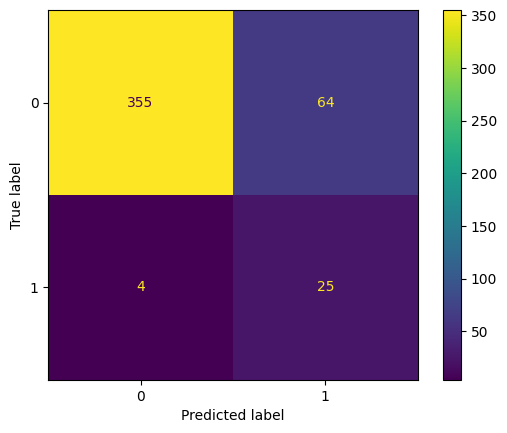

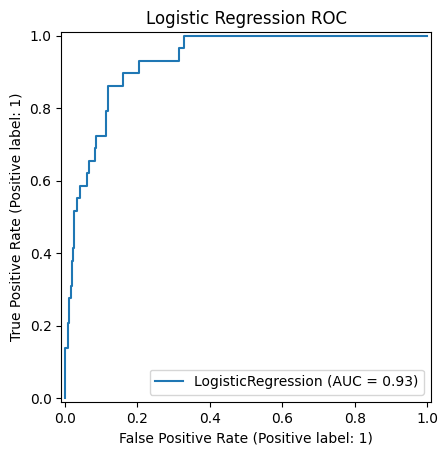

=== Random Forest on PC1/PC2 ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       419
           1       0.55      0.41      0.47        29

    accuracy                           0.94       448
   macro avg       0.75      0.69      0.72       448
weighted avg       0.93      0.94      0.94       448

ROC AUC: 0.9244095136202782


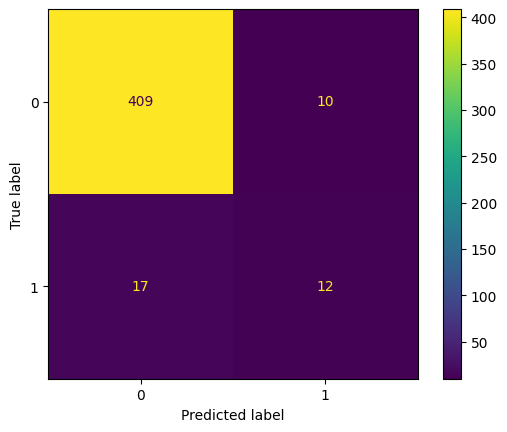

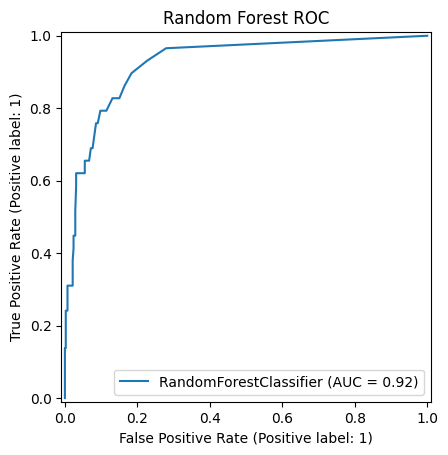

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Feature Matrix
pc = pc_df.reset_index(drop=True) 
response = df_marketing["AcceptedCmp1"].reset_index(drop=True)  

data = pd.concat([pc, response.rename("AcceptedCmp1")], axis=1)

# Train/Test
X = data[["PC1", "PC2"]]
y = data["AcceptedCmp1"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=0
)

# Log Re
logreg = LogisticRegression(class_weight="balanced", solver="liblinear", random_state=0)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression on PC1/PC2 ===")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))
ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test)
RocCurveDisplay.from_estimator(logreg, X_test, y_test)
plt.title("Logistic Regression ROC")
plt.show()

# RF
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=0
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest on PC1/PC2 ===")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest ROC")
plt.show()


In [16]:
cmp_cols = [f"AcceptedCmp{i}" for i in [1,2,3,4,5]]
print("Total accepts per campaign:")
print(df_marketing[cmp_cols].sum())


Total accepts per campaign:
AcceptedCmp1    144
AcceptedCmp2     30
AcceptedCmp3    163
AcceptedCmp4    167
AcceptedCmp5    163
dtype: int64


In [17]:
for col in cmp_cols:
    print(f"\n{col} vs Response:")
    print(pd.crosstab(df_marketing[col], df_marketing["Response"], margins=True))



AcceptedCmp1 vs Response:
Response         0    1   All
AcceptedCmp1                 
0             1841  255  2096
1               65   79   144
All           1906  334  2240

AcceptedCmp2 vs Response:
Response         0    1   All
AcceptedCmp2                 
0             1896  314  2210
1               10   20    30
All           1906  334  2240

AcceptedCmp3 vs Response:
Response         0    1   All
AcceptedCmp3                 
0             1820  257  2077
1               86   77   163
All           1906  334  2240

AcceptedCmp4 vs Response:
Response         0    1   All
AcceptedCmp4                 
0             1801  272  2073
1              105   62   167
All           1906  334  2240

AcceptedCmp5 vs Response:
Response         0    1   All
AcceptedCmp5                 
0             1835  242  2077
1               71   92   163
All           1906  334  2240


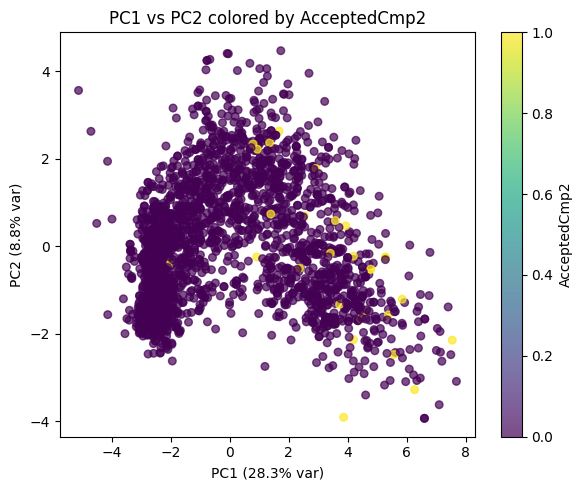

In [ ]:
#Accp Camp 2

# Response 
response = df_marketing["AcceptedCmp2"].reset_index(drop=True) 

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    pc_df["PC1"], pc_df["PC2"],
    c=response,                
    cmap="viridis",           
    alpha=0.7,
    s=30
)
plt.colorbar(scatter, label="AcceptedCmp2")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 colored by AcceptedCmp2")
plt.tight_layout()
plt.show()


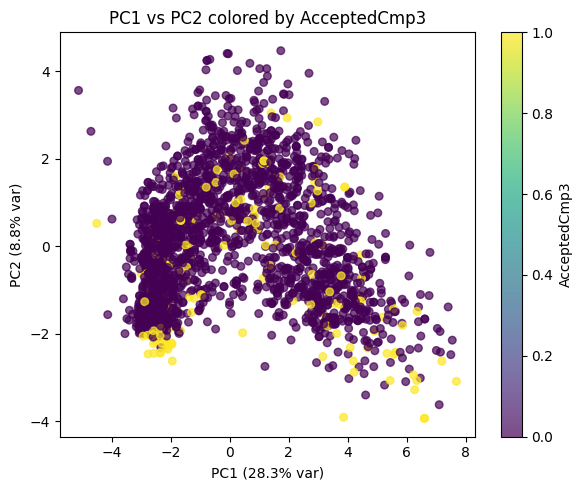

In [ ]:
#Accp Camp 3

# Response 
response = df_marketing["AcceptedCmp3"].reset_index(drop=True) 

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    pc_df["PC1"], pc_df["PC2"],
    c=response,                
    cmap="viridis",           
    alpha=0.7,
    s=30
)
plt.colorbar(scatter, label="AcceptedCmp3")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 colored by AcceptedCmp3")
plt.tight_layout()
plt.show()

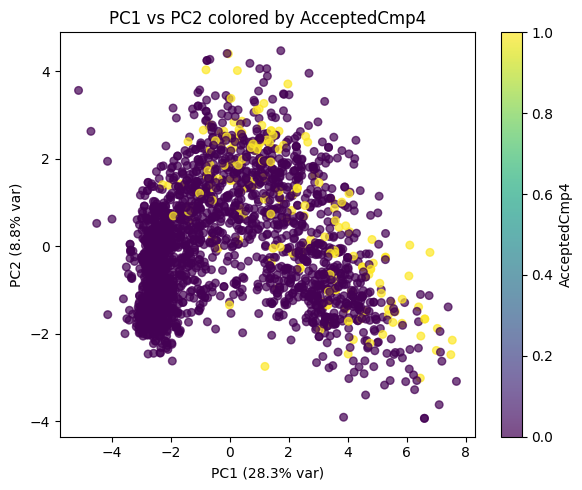

In [ ]:
#Accp Camp 4

# Response 
response = df_marketing["AcceptedCmp4"].reset_index(drop=True) 

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    pc_df["PC1"], pc_df["PC2"],
    c=response,                
    cmap="viridis",           
    alpha=0.7,
    s=30
)
plt.colorbar(scatter, label="AcceptedCmp4")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 colored by AcceptedCmp4")
plt.tight_layout()
plt.show()

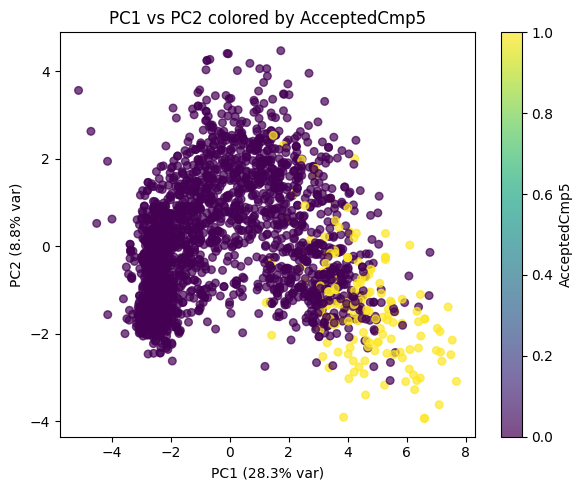

In [ ]:
#Accp Camp 5

# Response 
response = df_marketing["AcceptedCmp5"].reset_index(drop=True) 

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    pc_df["PC1"], pc_df["PC2"],
    c=response,                
    cmap="viridis",           
    alpha=0.7,
    s=30
)
plt.colorbar(scatter, label="AcceptedCmp5")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 colored by AcceptedCmp5")
plt.tight_layout()
plt.show()

In [26]:
df_marketing["Income_missing_flag"] = df_marketing["Income"].isna().astype(int)


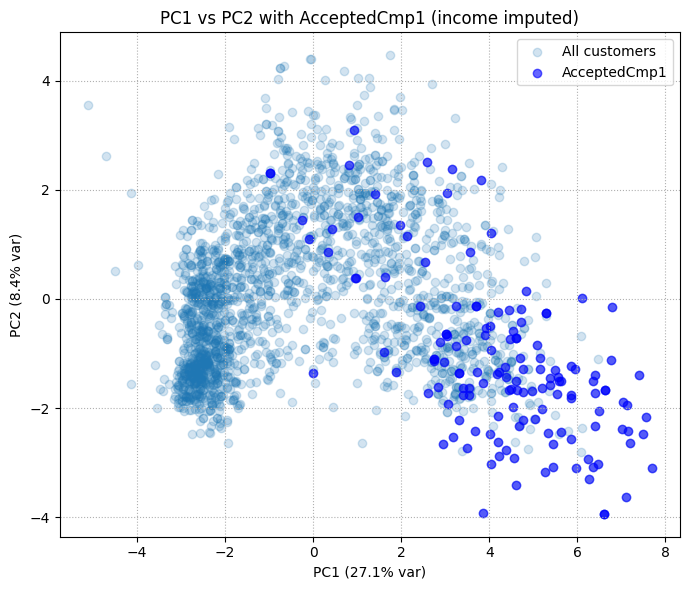

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Clean Missing
numeric_df = df_marketing.select_dtypes(include=["number"]).drop(columns=["ID"], errors="ignore")
numeric_df["Income_missing_flag"] = df_marketing["Income"].isna().astype(int)

# Impute
imputer = SimpleImputer(strategy="median")
imputed = pd.DataFrame(imputer.fit_transform(numeric_df), columns=numeric_df.columns)

# Standardize
scaler = StandardScaler()
Z = scaler.fit_transform(imputed)

# PCA 
pca = PCA(n_components=2)
pc_scores = pca.fit_transform(Z)
explained_var = pca.explained_variance_ratio_

# Scatter plot 
pc1 = pc_scores[:, 0]
pc2 = pc_scores[:, 1]
mask_cmp1 = df_marketing["AcceptedCmp1"] == 1

plt.figure(figsize=(7,6))
plt.scatter(pc1, pc2, alpha=0.2, label="All customers")
plt.scatter(pc1[mask_cmp1], pc2[mask_cmp1], color="blue", alpha=0.6, label="AcceptedCmp1")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 with AcceptedCmp1 (income imputed)")
plt.legend()
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()




In [29]:
mask_cmp1 = df_marketing["AcceptedCmp1"] == 1
accepted_scores = pc_scores[mask_cmp1]  # from your PCA output
center = accepted_scores.mean(axis=0)    # mean over PC1 and PC2
print("AcceptedCmp1 centroid (PC1, PC2):", center)


AcceptedCmp1 centroid (PC1, PC2): [ 4.2724336  -1.17647026]


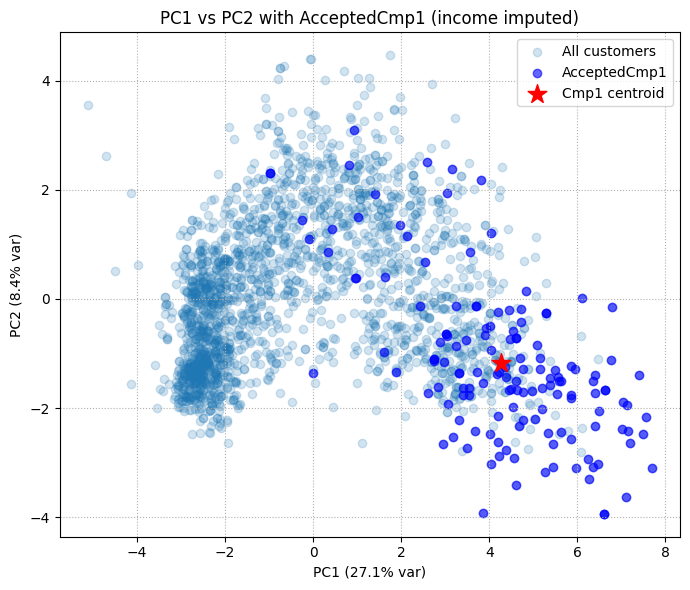

In [30]:
plt.figure(figsize=(7,6))
plt.scatter(pc1, pc2, alpha=0.2, label="All customers")
plt.scatter(pc1[mask_cmp1], pc2[mask_cmp1], color="blue", alpha=0.6, label="AcceptedCmp1")
plt.scatter(center[0], center[1], color="red", marker="*", s=200, label="Cmp1 centroid")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 with AcceptedCmp1 (income imputed)")
plt.legend()
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()


In [ ]:
feature_names = numeric_df.columns.tolist()  
pc1_loadings = pca.components_[0]
pc2_loadings = pca.components_[1]

# Top contributors 
top_pc1 = sorted(zip(feature_names, pc1_loadings), key=lambda x: abs(x[1]), reverse=True)[:5]
top_pc2 = sorted(zip(feature_names, pc2_loadings), key=lambda x: abs(x[1]), reverse=True)[:5]
print("Top features on PC1:", top_pc1)
print("Top features on PC2:", top_pc2)


Top features on PC1: [('NumCatalogPurchases', np.float64(0.31864862878394773)), ('MntMeatProducts', np.float64(0.3124226121017702)), ('MntWines', np.float64(0.30643141220252823)), ('Income', np.float64(0.29091527672260786)), ('NumStorePurchases', np.float64(0.2828138632999706))]
Top features on PC2: [('Teenhome', np.float64(0.5407069304774662)), ('NumDealsPurchases', np.float64(0.4576221718790217)), ('NumWebPurchases', np.float64(0.3521629308572987)), ('Year_Birth', np.float64(-0.3420381763122276)), ('NumStorePurchases', np.float64(0.2132711930427486))]


In [32]:
accepted_profile = df_marketing[mask_cmp1][numeric_df.columns].mean()
overall_profile = df_marketing[numeric_df.columns].mean()
profile_diff = pd.DataFrame({
    "AcceptedCmp1_mean": accepted_profile,
    "Overall_mean": overall_profile,
    "Delta": accepted_profile - overall_profile
}).sort_values("Delta", ascending=False)
print(profile_diff.head(10))


                     AcceptedCmp1_mean  Overall_mean         Delta
Income                    78872.626761  52247.251354  26625.375407
MntWines                    758.604167    303.935714    454.668452
MntMeatProducts             433.638889    166.950000    266.688889
MntFishProducts              91.861111     37.525446     54.335665
MntSweetProducts             65.138889     27.062946     38.075942
MntGoldProds                 77.131944     44.021875     33.110069
MntFruits                    55.847222     26.302232     29.544990
NumCatalogPurchases           6.097222      2.662054      3.435169
NumStorePurchases             8.062500      5.790179      2.272321
NumWebPurchases               5.729167      4.084821      1.644345


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.84      0.91       419
           1       0.29      0.90      0.43        29

    accuracy                           0.85       448
   macro avg       0.64      0.87      0.67       448
weighted avg       0.95      0.85      0.88       448

ROC AUC: 0.9291416344333799


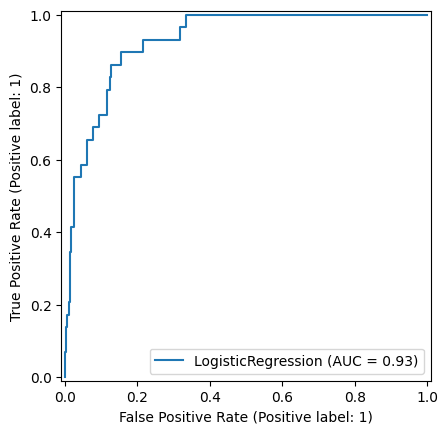

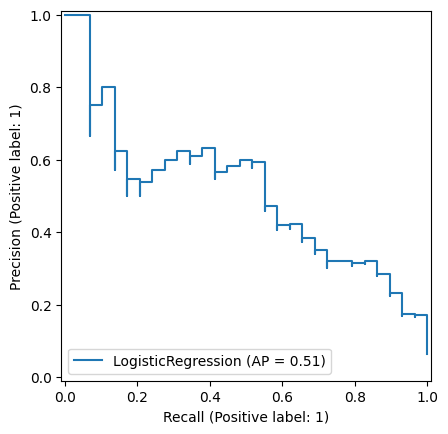

Random Forest
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       419
           1       0.58      0.38      0.46        29

    accuracy                           0.94       448
   macro avg       0.77      0.68      0.71       448
weighted avg       0.93      0.94      0.94       448

ROC AUC: 0.8984034235865361


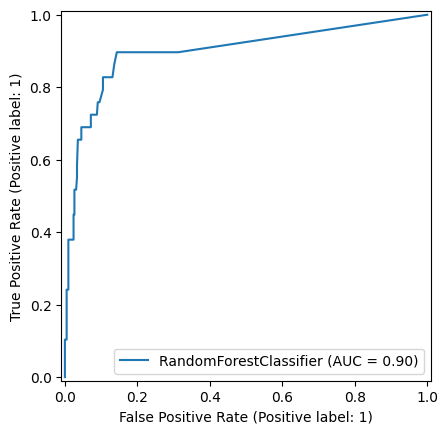

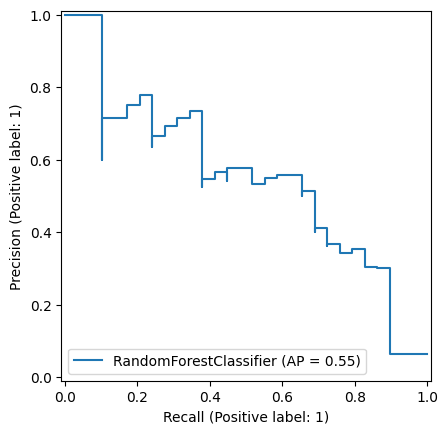

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, PrecisionRecallDisplay, RocCurveDisplay
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.distance import cdist

pc1 = pc_scores[:, 0]
pc2 = pc_scores[:, 1]
mask_cmp1 = df_marketing["AcceptedCmp1"] == 1

# Centroid
centroid = pc_scores[mask_cmp1][:, :2].mean(axis=0)
distances = cdist(pc_scores[:, :2], centroid.reshape(1, -1), metric="euclidean").flatten()
df_marketing["early_responder_score"] = -distances  # higher = closer

# Features
features = pd.DataFrame({
    "PC1": pc1,
    "PC2": pc2,
    "early_responder_score": df_marketing["early_responder_score"],
})
y = df_marketing["AcceptedCmp1"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features, y, stratify=y, test_size=0.2, random_state=0
)

# Logistic Regression 
logreg = LogisticRegression(class_weight="balanced", solver="liblinear", random_state=0)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))
RocCurveDisplay.from_estimator(logreg, X_test, y_test)
PrecisionRecallDisplay.from_estimator(logreg, X_test, y_test)
plt.show()

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=0)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
RocCurveDisplay.from_estimator(rf, X_test, y_test)
PrecisionRecallDisplay.from_estimator(rf, X_test, y_test)
plt.show()
